## Day14_Probability_Distributions

Part A — meet the distributions

TASK 01
Sample and characterise all five

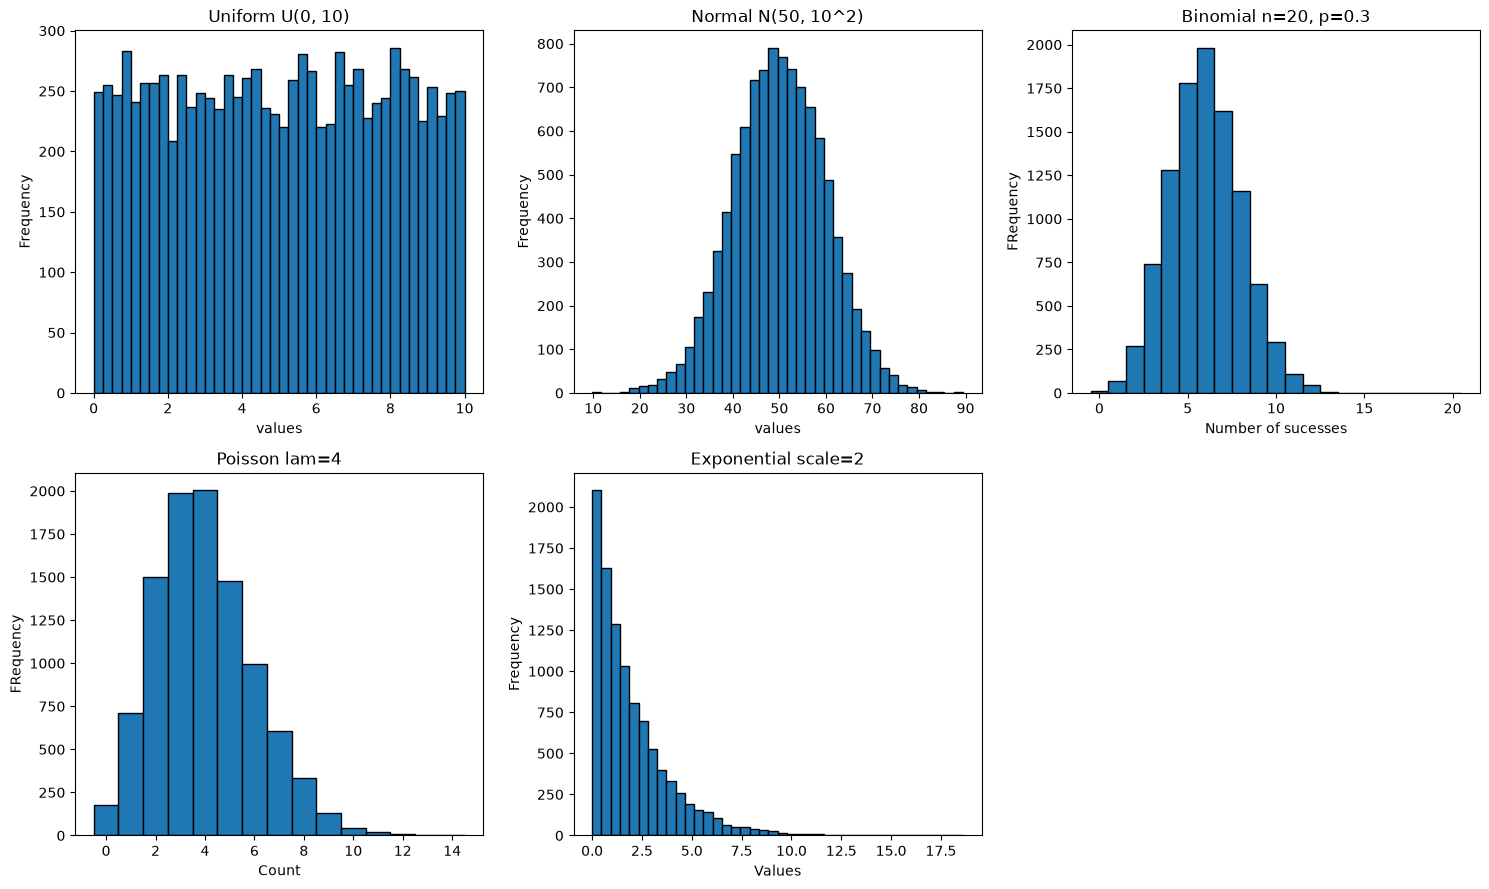

SAMPLE MEAN AND VARIANCE vs THEORETICAL VALUES

Uniform
 Sample mean       : 4.994107
 Theoretical mean  : 5.0000
 Sample varience   : 8.3550
 Theoretical var   : 8.3333

Normal
 Sample mean       : 50.044518
 Theoretical mean  : 50.0000
 Sample varience   : 98.5139
 Theoretical var   : 100.0000

Binomial
 Sample mean       : 5.980400
 Theoretical mean  : 6.0000
 Sample varience   : 4.1514
 Theoretical var   : 4.2000

Poisson
 Sample mean       : 3.994000
 Theoretical mean  : 4.0000
 Sample varience   : 3.9930
 Theoretical var   : 4.0000

Exponential
 Sample mean       : 1.983883
 Theoretical mean  : 2.0000
 Sample varience   : 3.8951
 Theoretical var   : 4.0000

POISSON CHECK
Poisson sample mean     : 3.9940
Poisson sample variance : 3.9930
Theory: mean = variance = lam = 4


In [ ]:
import numpy as np
import matplotlib.pyplot as plt 
from scipy import stats 


# ---------------------------------------------------------
# Setup
# ---------------------------------------------------------

rng = np.random.default_rng(0)
N = 10_000

# ---------------------------------------------------------
# 1. Generate samples
# ---------------------------------------------------------

# Uniform : U(0, 10)
u = rng.uniform(0, 10, N)

# Normal : N(50, 10^2)
n = rng.normal(50, 10, N)

# Binomial : X ~ Binomial(n=20, p=0.3)
b = rng.binomial(20, 0.3, N)

# Poisson : X ~ Poisson(4, N)
p = rng.poisson(4, N)

# Exponential : scale = 2
e = rng.exponential(2, N)


# ---------------------------------------------------------
# 2. Theoretical mean and variance
# ---------------------------------------------------------

theory = {
    "Uniform" : (5, 25 / 3),
    "Normal" : (50, 100),
    "Binomial" : (20 * 0.3, 20 * 0.3 * 0.7),
    "Poisson" : (4, 4),
    "Exponential" : (2, 4)
}

samples = {
    "Uniform" : u,
    "Normal" : n,
    "Binomial" : b,
    "Poisson" : p,
    "Exponential" : e
}


# ---------------------------------------------------------
# 3. Plot all five distributions
# ---------------------------------------------------------

fig, axes = plt.subplots(2, 3, figsize=(15, 9))

# Uniform
axes[0, 0].hist(u, bins=40, edgecolor="black")
axes[0, 0].set_title("Uniform U(0, 10)")
axes[0, 0].set_xlabel("values")
axes[0, 0].set_ylabel("Frequency")

# Normal
axes[0, 1].hist(n, bins=40, edgecolor="black")
axes[0, 1].set_title("Normal N(50, 10^2)")
axes[0, 1].set_xlabel("values")
axes[0, 1].set_ylabel("Frequency")

# Binomial
axes[0, 2].hist(b, bins=np.arange(-0.5, 21.5, 1), edgecolor="black")
axes[0, 2].set_title("Binomial n=20, p=0.3")
axes[0, 2].set_xlabel("Number of sucesses")
axes[0, 2].set_ylabel("FRequency")

# Poisson
axes[1, 0].hist(p, bins=np.arange(-0.5, 15.5, 1), edgecolor="black")
axes[1, 0].set_title("Poisson lam=4")
axes[1, 0].set_xlabel("Count")
axes[1, 0].set_ylabel("FRequency")

#  Exponential
axes[1, 1].hist(e, bins=40, edgecolor="black")
axes[1, 1].set_title("Exponential scale=2")
axes[1, 1].set_xlabel("Values")
axes[1, 1].set_ylabel("Frequency")

# Emply sixth subplot
axes[1, 2].axis("off")

plt.tight_layout()
plt.show()


# ---------------------------------------------------------
# 4. Compare sample statistics with theory
# ---------------------------------------------------------

print("=" * 75)
print("SAMPLE MEAN AND VARIANCE vs THEORETICAL VALUES")
print("=" * 75)

for name, data in samples.items():
    sample_mean = data.mean()
    sample_var = data.var()
    
    theoretical_mean, theoretical_var = theory[name]
    
    print(f"\n{name}")
    print(f" Sample mean       : {sample_mean:04f}")
    print(f" Theoretical mean  : {theoretical_mean:.4f}")
    print(f" Sample varience   : {sample_var:.4f}")
    print(f" Theoretical var   : {theoretical_var:.4f}")
    
    
# ---------------------------------------------------------
# 5. Check Poisson signature
# ---------------------------------------------------------

print("\n" + "=" * 75)
print("POISSON CHECK")
print("=" * 75)

print(f"Poisson sample mean     : {p.mean():.4f}")
print(f"Poisson sample variance : {p.var():.4f}")
print("Theory: mean = variance = lam = 4")

Uniform     : Models a quantity where every value in a fixed range is equally likely.

Normal      : Models measurements such as heights, test scores, or measurement errors.

Binomial    : Models the number of successes in a fixed number of independent trials.

Poisson     : Models the number of events occurring in a fixed time or space interval.

Exponential : Models the waiting time until the next event occurs.

### Probability Distributions — Short Answers

**1. What is the theoretical mean and variance of each?**

| Distribution    | Mean      | Variance    |
| --------------- | --------- | ----------- |
| **Uniform**     | `(a+b)/2` | `(b-a)²/12` |
| **Normal**      | `μ`       | `σ²`        |
| **Binomial**    | `np`      | `np(1-p)`   |
| **Poisson**     | `λ`       | `λ`         |
| **Exponential** | `scale`   | `scale²`    |

**Definition:** The **theoretical mean** is the expected average value, while **variance** measures how much the values spread around the mean.

---

**2. Which distributions are discrete and continuous?**

* **Discrete:** Binomial, Poisson — values are countable, usually whole numbers.
* **Continuous:** Uniform, Normal, Exponential — values can take any value within their range.

**Definition:** A **discrete distribution** has countable outcomes, while a **continuous distribution** can take any value in an interval.

---

**3. Which are bounded and unbounded?**

* **Bounded:** Uniform, Binomial.
* **Unbounded:** Normal, Poisson, Exponential.

**Definition:** A **bounded distribution** has fixed limits on its possible values. An **unbounded distribution** has no fixed upper limit.


TASK 02
The 68-95-99.7 rule

In [8]:
import numpy as np
from scipy import stats

# Reproducible random generator
rng = np.random.default_rng(0)

# Noraml Distribution
mu = 50
sigma = 10

# Generate 100,000 samples
sample = rng.normal(mu, sigma, 100_000)


# -----------------------------
# Simulation
# -----------------------------

within1 = np.mean(np.abs(sample - mu) < sigma)
within2 = np.mean(np.abs(sample - mu) < 2 * sigma)
within3 = np.mean(np.abs(sample - mu) < 3 * sigma)

print("SIMULATION")
print(f"Within 1 SD : {within1:.4f} = {within1*100:.2f}%")
print(f"Within 2 SD : {within2:.4f} = {within2*100:.2f}%")
print(f"Within 3 SD : {within3:.4f} = {within3*100:.2f}%")

# -----------------------------
# Theory using scipy.stats.norm.cdf
# -----------------------------

theory1 = stats.norm.cdf(1) - stats.norm.cdf(-1)
theory2 = stats.norm.cdf(2) - stats.norm.cdf(-2)
theory3 = stats.norm.cdf(3) - stats.norm.cdf(-3)

print("\nTHEORY")
print(f"Within 1 SD : {theory1:.4f} = {theory1*100:.2f}%")
print(f"Within 2 SD : {theory2:.4f} = {theory2*100:.2f}%")
print(f"Within 3 SD : {theory3:.4f} = {theory3*100:.2f}%")

# -----------------------------
# Value 2 SD above the mean
# -----------------------------

above_2sd = 1 - stats.norm.cdf(2)

print("\nABOVE 2 SD")
print(f"Fraction above +2 SD : {above_2sd:.4f}")
print(f"Percentage : {above_2sd*100:.2f}%")

# -----------------------------
# Percentile of +1 SD
# -----------------------------

percentile_1sd = stats.norm.cdf(1)

print("\nPERCENTILE")
print(f"+1d SD is at the {percentile_1sd*100:.2f}th percentile")

SIMULATION
Within 1 SD : 0.6839 = 68.39%
Within 2 SD : 0.9546 = 95.46%
Within 3 SD : 0.9971 = 99.71%

THEORY
Within 1 SD : 0.6827 = 68.27%
Within 2 SD : 0.9545 = 95.45%
Within 3 SD : 0.9973 = 99.73%

ABOVE 2 SD
Fraction above +2 SD : 0.0228
Percentage : 2.28%

PERCENTILE
+1d SD is at the 84.13th percentile


### TASK 02 — Meaningful Answers

**1. Why is the 68-95-99.7 rule the same for every normal distribution?**
Every normal distribution has the same **bell-shaped standardized form**. Changing the mean shifts the curve, and changing the standard deviation stretches or compresses it, but the percentage of values within 1, 2, and 3 standard deviations remains the same.

**2. What is a z-score?**
A **z-score** tells us how many standard deviations a value is away from the mean.

$$
z=\frac{x-\mu}{\sigma}
$$

* `z = 0` → exactly at the mean
* `z = 1` → 1 standard deviation above the mean
* `z = -2` → 2 standard deviations below the mean

**3. Why are values beyond 3 standard deviations considered rare outliers?**
In a normal distribution, about **99.7%** of values fall within 3 standard deviations of the mean. Therefore, only about **0.3%** lie outside this range, making them unusually rare and potential outliers.

**4. Percentile interpretation:**
A value **1 SD above the mean** is approximately at the **84.13th percentile**. A value **2 SD above** is about the **97.72nd percentile**.


Part B — the Central Limit Theorem

TASK 03
Verify the CLT empirically

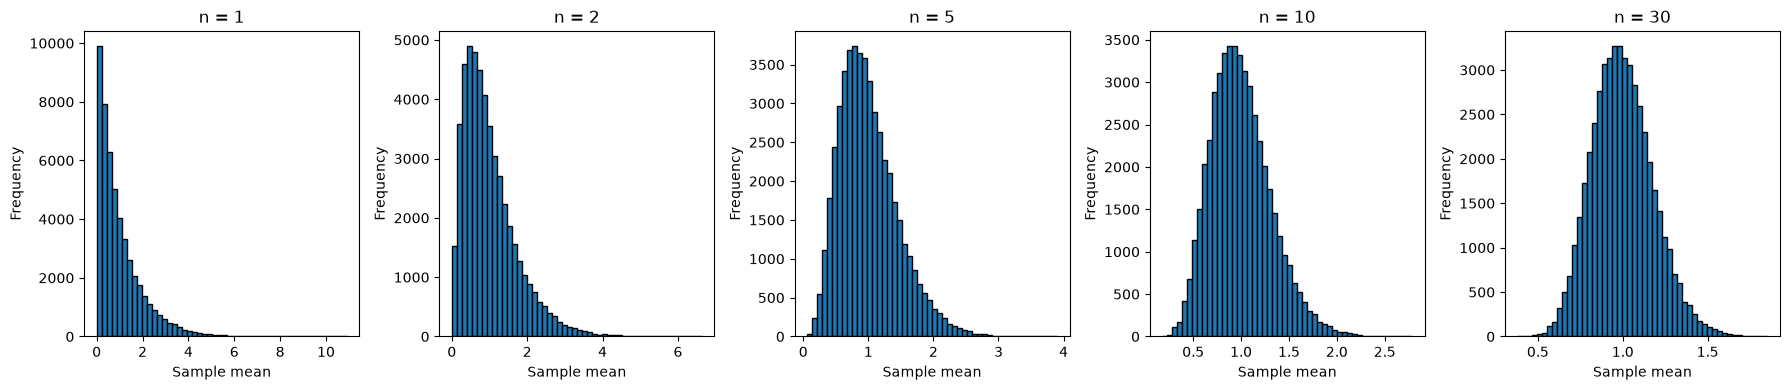

Standard deviation of sample means:
---------------------------------------------
n =  1 | Sample SD = 0.9979 | Theoretical SD =1.0000
n =  2 | Sample SD = 0.6989 | Theoretical SD =0.7071
n =  5 | Sample SD = 0.4483 | Theoretical SD =0.4472
n = 10 | Sample SD = 0.3164 | Theoretical SD =0.3162
n = 30 | Sample SD = 0.1823 | Theoretical SD =0.1826


In [13]:
import numpy as np
import matplotlib.pyplot as plt

# Reproducible random generator
rng = np.random.default_rng(0)

# Generate many sample means
def sample_means(n, reps=50_000):
    return np.array([
        rng.exponential(1, n).mean()
        for _ in range(reps)
    ]) 
    
# Sample Sizes    
sample_sizes = [1, 2, 5, 10, 30]

# Plot distributions of sample means
fig, axes = plt.subplots(1, 5, figsize=(18, 4))

for ax, n in zip(axes, sample_sizes):
    means = sample_means(n)
    
    ax.hist(means, bins=50, edgecolor="black")
    ax.set_title(f"n = {n}")
    ax.set_xlabel("Sample mean")
    ax.set_ylabel("Frequency")
    
plt.tight_layout()
plt.show()


# ---------------------------------------------------------
# Check CLT spread prediction
# ---------------------------------------------------------

print("Standard deviation of sample means:")
print("-" * 45)   

for n in sample_sizes:
    means = sample_means(n)
    
    theoretical_sd = 1 / np.sqrt(n)
    
    print(
        f"n = {n:2d} | "
        f"Sample SD = {means.std():.4f} | "
        f"Theoretical SD ={theoretical_sd:.4f}"
    ) 

Q. the CLT means the normal distribution appears so often
in nature

-> The CLT explains why normal distributions appear so often because averages combine the effects of many independent random factors. As more observations are averaged together, unusual values tend to balance each other out, producing a distribution that becomes approximately bell-shaped.

### Task 03 

**1. Why does averaging create a bell shape?**
The **Central Limit Theorem (CLT)** says that averages of many independent observations tend to form a **normal (bell-shaped) distribution**, even if the original data is not normal.

**2. Why does the spread shrink?**
The standard error is:

$$
SE=\frac{\sigma}{\sqrt{n}}
$$

Larger `n` → smaller spread → averages are more stable and reliable.

**3. Where is CLT used in ML/Data Science?**
Used in **confidence intervals, hypothesis testing, A/B testing, sampling, and estimating model performance**.

**Key result:**
`n ↑ → spread ↓ → estimate reliability ↑`


Part C — PDF, CDF, and fitting

TASK 04
PDF and CDF

NORMAL DISTRIBUTION
-------------------
Fraction below x = 1.0 : 0.8413
Fraction above x = 1.0 : 0.1587
Fraction below mean : 0.5000
90th Percentile : -1.3408


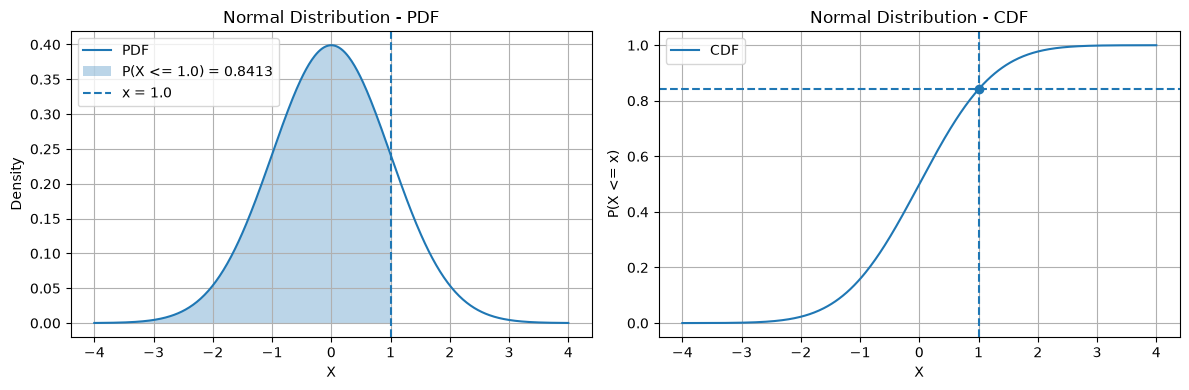

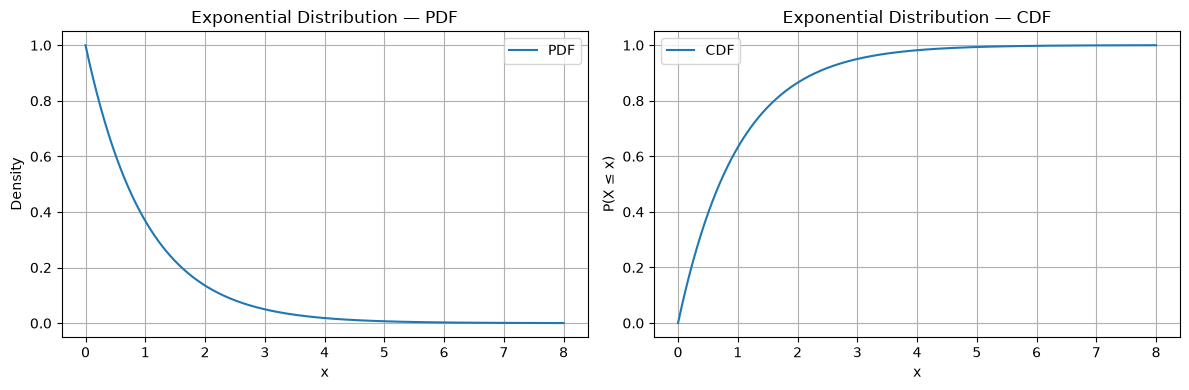

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats


# ------------------------------------------------------------
# 1. NORMAL DISTRIBUTION
# ------------------------------------------------------------

# Create x values
x = np.linspace(-4, 4, 500)

# Normal distribution: mean = 0, standard deviation = 1
pdf = stats.norm.pdf(x)
cdf = stats.norm.cdf(x)

# Choose a value x0
x0 = 1.0

# CDF gives P(X <= x0)
prob_below_x0 = stats.norm.cdf(x0)

# Probability above x0
prob_above_x0 = 1 - prob_below_x0

# Probability below the mean
prob_below_mean = stats.norm.cdf(0)

# 90th percentile using inverse CDF
p90 = stats.norm.ppf(0.090)

print("NORMAL DISTRIBUTION")
print("-------------------")
print(f"Fraction below x = {x0} : {prob_below_x0:.4f}")
print(f"Fraction above x = {x0} : {prob_above_x0:.4f}")
print(f"Fraction below mean : {prob_below_mean:.4f}")
print(f"90th Percentile : {p90:.4f}")


# ------------------------------------------------------------
# 2. PLOT PDF AND CDF
# ------------------------------------------------------------

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# PDF
axes[0].plot(x, pdf, label="PDF")

# Shade area to the left of x0
x_fill = np.linspace(-4, x0, 300)
axes[0].fill_between(
    x_fill,
    stats.norm.pdf(x_fill),
    alpha=0.3,
    label=f"P(X <= {x0}) = {prob_below_x0:.4f}"
)

axes[0].axvline(x0, linestyle="--", label=f"x = {x0}")
axes[0].set_title("Normal Distribution - PDF")
axes[0].set_xlabel("X")
axes[0].set_ylabel("Density")
axes[0].legend()
axes[0].grid(True)

# ---------- CDF ----------
axes[1].plot(x, cdf, label="CDF")

# Mark CDF value at x0
axes[1].scatter(x0, prob_below_x0, zorder=5)

axes[1].axvline(x0, linestyle="--")
axes[1].axhline(prob_below_x0, linestyle="--")

axes[1].set_title("Normal Distribution - CDF")
axes[1].set_xlabel("X")
axes[1].set_ylabel("P(X <= x)")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 3. EXPONENTIAL DISTRIBUTION — SKEWED DISTRIBUTION
# ------------------------------------------------------------

x_exp = np.linspace(0, 8, 500)

# Exponential distribution with scale = 1
pdf_exp = stats.expon.pdf(x_exp)
cdf_exp = stats.expon.cdf(x_exp)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Exponential PDF
axes[0].plot(x_exp, pdf_exp, label="PDF")
axes[0].set_title("Exponential Distribution — PDF")
axes[0].set_xlabel("x")
axes[0].set_ylabel("Density")
axes[0].legend()
axes[0].grid(True)

# Exponential CDF
axes[1].plot(x_exp, cdf_exp, label="CDF")
axes[1].set_title("Exponential Distribution — CDF")
axes[1].set_xlabel("x")
axes[1].set_ylabel("P(X ≤ x)")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

What the results mean

For the standard normal distribution:

PDF → shows the density/shape of possible values.

CDF → gives the probability that X is less than or equal to a value.

### Task 4

**1. Why does area under the PDF correspond to a value on the CDF?**
The PDF shows probability density. The **area under the PDF up to x** gives the total probability up to x, which is exactly the **CDF value**.

**2. Why can the CDF never go down?**
Because probability can only **increase or stay the same** as we include more values. It starts at **0** and approaches **1**.

**3. What does `ppf` (inverse CDF) do, and when is it useful?**
`ppf` finds the **value corresponding to a given probability/percentile**. It is useful for finding percentiles, such as the **90th percentile**.


TASK 05
Fit a distribution to real data

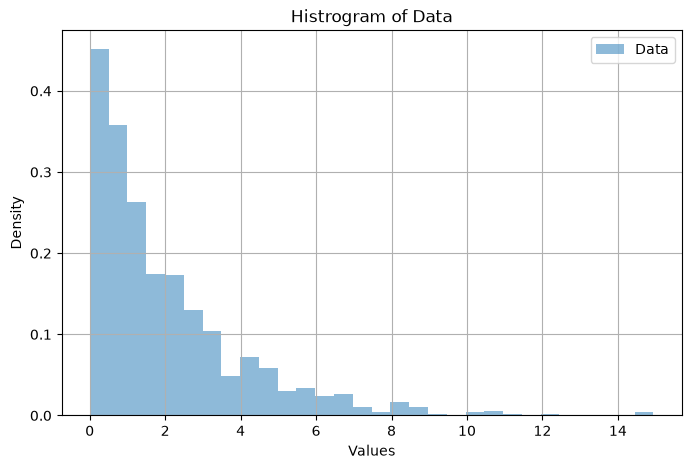

Normal Parameters : 
Mean (mu) :  2.0287
Std (Sigma) :  2.0542
Exponential PArameters : 
Location :  0.0022
Scale :  2.0265


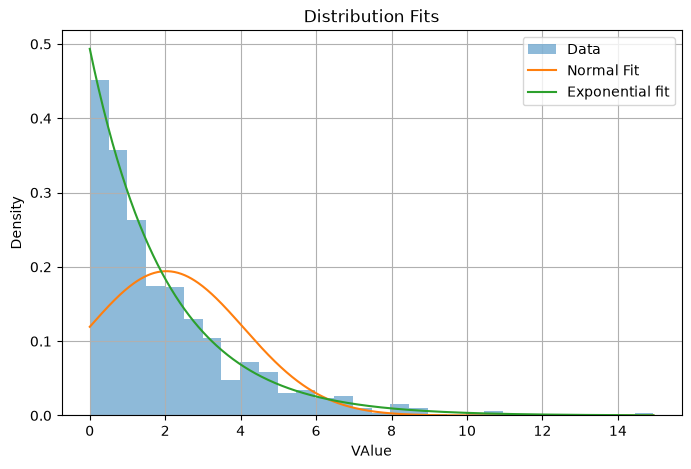


Log-likelihood
Normal      :  -2138.82
Exponential :  -1706.31

Better fit : Exponential


In [17]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# ------------------------------------------------------------
# 1. Create realistic data
# ------------------------------------------------------------

rng = np.random.default_rng(42)

# Generate data from an exponential distribution
data = rng.exponential(scale=2, size=1000)

# Pretend we don't know the original distribution

# ------------------------------------------------------------
# 2. Plot histogram
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))

plt.hist(
    data,
    bins=30,
    density=True,
    alpha=0.5,
    label="Data"
)

plt.title("Histrogram of Data")
plt.xlabel("Values")
plt.ylabel("Density")
plt.legend()
plt.grid(True)

plt.show()


# ------------------------------------------------------------
# 3. Fit two candidate distributions
# ------------------------------------------------------------

# Normal fit
mu, sigma = stats.norm.fit(data)

# Exponential fit
loc, scale = stats.expon.fit(data)

print("Normal Parameters : ")
print("Mean (mu) : ", round(mu, 4))
print("Std (Sigma) : ", round(sigma, 4))

print("Exponential PArameters : ")
print("Location : ", round(loc, 4))
print("Scale : ", round(scale, 4))


# ------------------------------------------------------------
# 4. Overlay fitted curves
# ------------------------------------------------------------

x = np.linspace(data.min(), data.max(), 500)

normal_pdf = stats.norm.pdf(x, mu, sigma)
expon_pdf = stats.expon.pdf(x, loc, scale)

plt.figure(figsize=(8, 5))

plt.hist(
    data,
    bins=30,
    density=True,
    alpha=0.5,
    label="Data"
)

plt.plot(x, normal_pdf, label="Normal Fit")
plt.plot(x, expon_pdf, label="Exponential fit")

plt.title("Distribution Fits")
plt.xlabel("VAlue")
plt.ylabel("Density")
plt.legend()
plt.grid(True)

plt.show()

# ------------------------------------------------------------
# 5. Compare using log-likelihood
# ------------------------------------------------------------

ll_norm = np.sum(stats.norm.logpdf(data, mu, sigma))
ll_expon = np.sum(stats.expon.logpdf(data, loc, scale))

print("\nLog-likelihood")
print("Normal      : ", round(ll_norm, 2))
print("Exponential : ", round(ll_expon, 2))

if ll_norm > ll_expon : 
    print("\nBette fit : Normal")
else : 
    print("\nBetter fit : Exponential")    

Que : Write two sentences: which distribution won, and what does that tell you about the process that generated the
data?

-> The **exponential distribution won** because it had the higher log-likelihood and matched the histogram better.

-> This suggests the data may come from a **random waiting-time process**, where events occur independently over time.


### Task_5 Short & Meaningful Answers

**1. Why might the eye and log-likelihood disagree?**
The eye focuses on the **visual shape**, while log-likelihood considers how well the distribution fits **every data point**.

**2. What does it mean practically to know which distribution your data follows?**
It helps us **model, predict, and estimate probabilities** more accurately.

**3. If none of the standard distributions fit well, what does that tell you?**
It may mean the data has a **complex shape, outliers, or comes from multiple processes**, so another model may be needed.
